### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [113]:
data = pd.read_csv('data/coupons.csv')

In [114]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [115]:
# Check for missing/null values
print("Missing values before cleaning:\n", data.isnull().sum())

# Keep track of the original dataset size
original_size = data.shape[0]

# Create original data size output
print("-" * 30)
print('There are', original_size, 'rows in the original dataset.')

Missing values before cleaning:
 destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64
------------------------------
There are 12684 rows in the original dataset.


3. Decide what to do about your missing data -- drop, replace, other...

In [116]:
# The 'car' column is almost completely empty, so drop the column.
data = data.drop(columns=['car'])

# Other columns with NaN values (Bar, CoffeeHouse, CarryAway, RestaurantLessThan20, Restaurant20To50), 
# make up a small percentage. We drop the rows with missing values to keep the data clean.
data = data.dropna()

# Get the post-cleaning dataste size and calculate differences
new_size = data.shape[0]
rows_dropped = original_size - new_size
percent_dropped = (rows_dropped / original_size) * 100

# Create data cleaning stats output
print("-" * 30)
print("Original number of rows:", original_size)
print("Number of rows after cleaning:", new_size)
print("Rows dropped:", rows_dropped)
print(f"Percentage of data dropped: {percent_dropped:.2f}%")

------------------------------
Original number of rows: 12684
Number of rows after cleaning: 12079
Rows dropped: 605
Percentage of data dropped: 4.77%


4. What proportion of the total observations chose to accept the coupon?



In [117]:
# Since the 'Y' column only contains 0 (for rejection) or 1 (for accepted), mean() provides a meaningful answer
# compared to median().
overall_acceptance_rate = data['Y'].mean()

# Create observation output
print(f"Overall coupon acceptance rate: {overall_acceptance_rate:.2%}")

Overall coupon acceptance rate: 56.93%


5. Use a bar plot to visualize the `coupon` column.

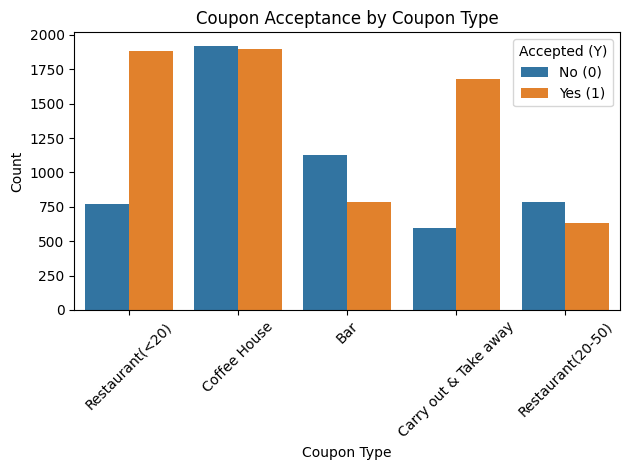

In [118]:
# Create visualization that aligns to rubric
sns.countplot(data=data, x='coupon', hue='Y')
plt.title('Coupon Acceptance by Coupon Type')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Accepted (Y)', labels=['No (0)', 'Yes (1)'])
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

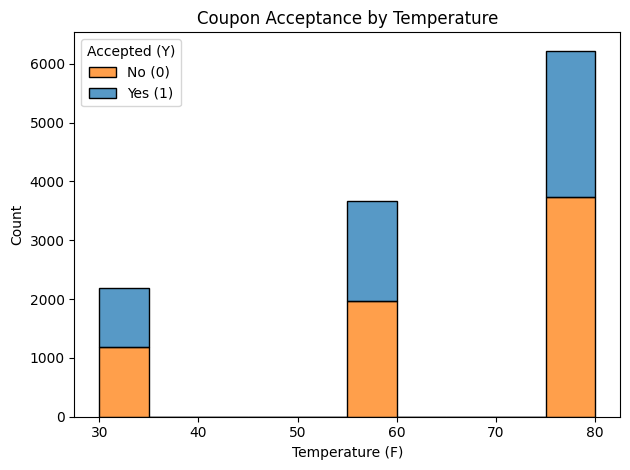

In [119]:
# Create visualization that aligns to rubric
sns.histplot(data=data, x='temperature', hue='Y', multiple="stack", bins=10)
plt.title('Coupon Acceptance by Temperature')
plt.xlabel('Temperature (F)')
plt.ylabel('Count')
plt.legend(title='Accepted (Y)', labels=['No (0)', 'Yes (1)'])
plt.tight_layout()
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [120]:
# Create (an imaginatively named) copy of the 'data' dataframe focusing on the Bar coupon
bar_data = data[data['coupon'] == 'Bar'].copy()

2. What proportion of bar coupons were accepted?


In [121]:
# Reuse the pattern from earlier for finding proportion using mean()
bar_acceptance_rate = bar_data['Y'].mean()

# Create answer output
print(f"Bar coupon acceptance rate: {bar_acceptance_rate:.2%}")

Bar coupon acceptance rate: 41.19%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [122]:
# First we use the unique values in 'Bar' ('never', 'less1', '1~3', '4~8', 'gt8')
# to create classifications that will be used for filtering
cat_three_or_fewer = ['never', 'less1', '1~3']
cat_more_than_three = ['4~8', 'gt8']

# Next we use those classifications to find the mean for each, using the same mean() pattern as earlier
rate_3_or_fewer = bar_data[bar_data['Bar'].isin(cat_three_or_fewer)]['Y'].mean()
rate_more_than_3 = bar_data[bar_data['Bar'].isin(cat_more_than_three)]['Y'].mean()

# Create answer output
print(f"Acceptance rate (3 or fewer times/month): {rate_3_or_fewer:.2%}")
print(f"Acceptance rate (More than 3 times/month): {rate_more_than_3:.2%}")

Acceptance rate (3 or fewer times/month): 37.27%
Acceptance rate (More than 3 times/month): 76.17%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [123]:
# First we use the unique values in 'Bar' ('never', 'less1', '1~3', '4~8', 'gt8')
# to create another set of classifications that will be used for filtering.
cat_more_than_once = ['1~3', '4~8', 'gt8']

# To work around 'age' being stored as a string, we create a filtered list of values to compare against later.
cat_over_25 = ['26', '31', '50plus', '36', '41', '46']

# Using the filters to compare we create a new group
group_4 = bar_data[(bar_data['Bar'].isin(cat_more_than_once)) & (bar_data['age'].isin(cat_over_25))]

# Reuse the mean() pattern to find the rate, then again to find the rate for everyone else
rate_group_4 = group_4['Y'].mean()
rate_others_4 = bar_data[~((bar_data['Bar'].isin(cat_more_than_once)) & (bar_data['age'].isin(cat_over_25)))]['Y'].mean()

# Create the output string/answer using the rates found above
print(f"Acceptance rate (>1/month & Age > 25): {rate_group_4:.2%}")
print(f"Acceptance rate (All others): {rate_others_4:.2%}")

Acceptance rate (>1/month & Age > 25): 68.98%
Acceptance rate (All others): 33.77%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [124]:
# We start by creating filters for the three criteria:
# 1. Drivers who go to bars more than once a month
cond_bar = bar_data['Bar'].isin(more_than_once)

# 2. Had passengers that were not a kid 
cond_passenger = bar_data['passanger'] != 'Kid(s)'

# 3. Had occupations other than farming, fishing, or forestry
cond_occupation = bar_data['occupation'] != 'Farming Fishing & Forestry'

# Use conditions to filter the data and create a new group
group_5 = bar_data[cond_bar & cond_passenger & cond_occupation]
rate_group_5 = group_5['Y'].mean()

# Filter rate_group_5 to create a new group for those who DO NOT fit the conditions
rate_others_5 = bar_data[~(cond_bar & cond_passenger & cond_occupation)]['Y'].mean()

# Create the output string/answer using the rates found above
print(f"Acceptance rate (Target Group): {rate_group_5:.2%}")
print(f"Acceptance rate (All Others): {rate_others_5:.2%}")

Acceptance rate (Target Group): 70.94%
Acceptance rate (All Others): 29.79%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [125]:
# We start by creating filters for the three criteria:
# 1. Go to bars more than once a month
cond_bar = bar_data['Bar'].isin(more_than_once)

# 2. Had passengers that were not a kid
cond_passenger = bar_data['passanger'] != 'Kid(s)'

# 3. Were not widowed
cond_marital = bar_data['maritalStatus'] != 'Widowed'

# Create the first group using the filters
group_1 = (bar_data['Bar'].isin(more_than_once)) & (bar_data['passanger'] != 'Kid(s)') & (bar_data['maritalStatus'] != 'Widowed')

# Find the rate for Group 1 using mean()
rate_group_1 = bar_data[group_1]['Y'].mean()

# First we use the values in 'age'
# to create another set of classifications that will be used for filtering.
under_30 = ['below21', '21', '26']

# We use the age filter to find everyone under the age of 30
cond_age = bar_data['age'].isin(under_30)

# Create the second group using the filters
group_2 = (bar_data['Bar'].isin(more_than_once)) & (bar_data['age'].isin(under_30))

# Find the rate for Group 2 using mean()
rate_group_2 = bar_data[group_2]['Y'].mean()

# First we use the values in 'RestaurantsLessThan20'
# to create another set of classifications that will be used for filtering.
cat_cheap_restaurants = ['4~8', 'gt8']

# Next we use the values in 'income'
# to create another set of classifications that will be used for filtering.
cat_income_under_50k = ['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']

# We use the cat_cheap_restaurants to filter for the restaurant condition
cond_restaurant = bar_data['RestaurantLessThan20'].isin(cat_cheap_restaurants)

# We use the cat_income_under_50k to filter for the correct income
cond_income = bar_data['income'].isin(cat_income_under_50k)

# Create a third group using the filters
group_3 = (bar_data['RestaurantLessThan20'].isin(cat_cheap_restaurants)) & (bar_data['income'].isin(cat_income_under_50k))

# Find the rate for group 3 using mean()
rate_group_3 = bar_data[group_3]['Y'].mean()

# Create the output string/answer using the rates found above
print(f"Group 1 (Bar >1/mo, No Kids, Not Widowed) Acceptance Rate: {rate_group_1:.2%}")
print(f"Group 2 (Bar >1/mo, Under 30) Acceptance Rate:             {rate_group_2:.2%}")
print(f"Group 3 (Cheap Rest. >4/mo, Income < 50K) Acceptance Rate: {rate_group_3:.2%}")

Group 1 (Bar >1/mo, No Kids, Not Widowed) Acceptance Rate: 70.94%
Group 2 (Bar >1/mo, Under 30) Acceptance Rate:             71.95%
Group 3 (Cheap Rest. >4/mo, Income < 50K) Acceptance Rate: 45.65%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Group 1 and Group 2 show higher propensity to accept the bar coupon than Group 3. We can hypothesize that
Group 3 who frequent cheap restaurants have less disposable income than Groups 1 & 2, and this may be due
to the frequency with which they spend at restaurants generally. Even if the restaurants are 'cheap', the
aggregate spend is high. We can further hypothesize that those who frequent bars more than once a month
will accept more of the coupons since it fits their habit/lifestyle.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [126]:
# Create a copy of the 'data' dataframe focusing on the Coffee House coupon
coffee_data = data[data['coupon'] == 'Coffee House'].copy()

In [127]:
# Find the proportion of coffee acceptance using mean()
coffee_acceptance_rate = coffee_data['Y'].mean()

# Create answer output
print(f"Coffee House coupon acceptance rate: {coffee_acceptance_rate:.2%}")

Coffee House coupon acceptance rate: 49.63%


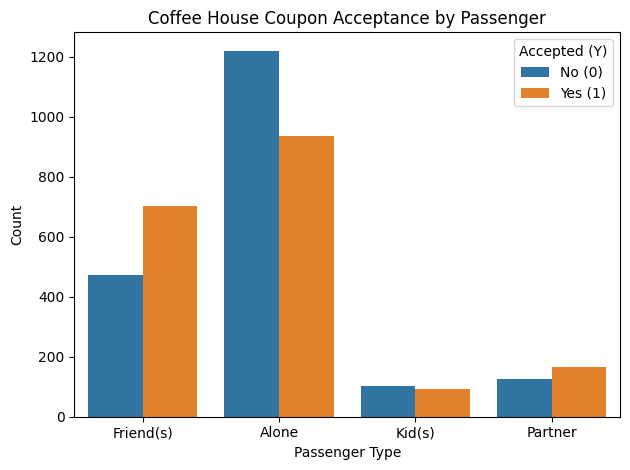

In [128]:
# Create visualization that aligns to rubric
# showing coupon acceptance across different passenger types 
sns.countplot(data=coffee_data, x='passanger', hue='Y')
plt.title('Coffee House Coupon Acceptance by Passenger')
plt.xlabel('Passenger Type')
plt.ylabel('Count')
plt.legend(title='Accepted (Y)', labels=['No (0)', 'Yes (1)'])
plt.tight_layout()
plt.show()

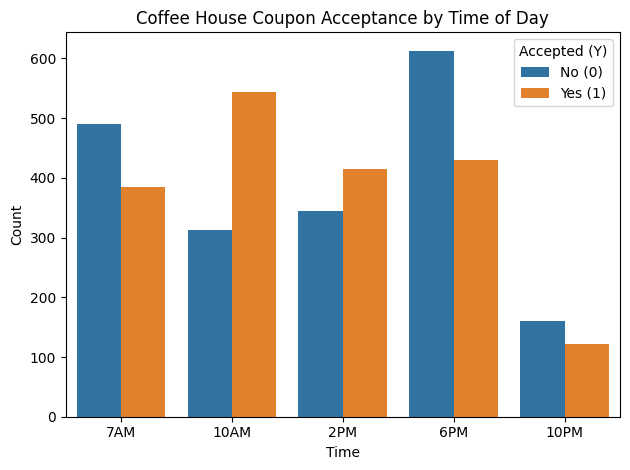

In [129]:
# Create visualization that aligns to rubric
# showing coupon acceptance across morning, late morning, afternoon, evening, and night
sns.countplot(data=coffee_data, x='time', hue='Y', order=['7AM', '10AM', '2PM', '6PM', '10PM'])
plt.title('Coffee House Coupon Acceptance by Time of Day')
plt.xlabel('Time')
plt.ylabel('Count')
plt.legend(title='Accepted (Y)', labels=['No (0)', 'Yes (1)'])
plt.tight_layout()
plt.show()

### Findings

1. Based on the Bar Coupon analysis we can hypothesize that Drivers who regularly frequent
   bars, more than once per month, are more 70% likely to accept the Bar Coupon. Compared to
   budget conscious drivers with income less than $50k who frequent 'cheap' restaurants
   who will only accept 45% of Bar Coupons offered. This indicates that habit is a higher
   driver (pardon the pun) to coupon acceptance.
2. Bar Coupon acceptance will significantly decrease when there are children passengers present.
3. Coffee House coupons have the highest acceptance rates at 10AM and 2PM, when they are
   likely to be taking a morning break or combating an 'afternoon slump'.
4. Coffee House coupons also show highest acceptance rates when a friend or partner are
   the passenger, but not when kids are the passenger.

### Recommendations

1. Focus on offering Bar Coupons to those who have historically frequented bars.
2. Send Coffee House Coupons to travelers with friends, partners, only in the late morning or early afternoons.